## Calculating the deviations due to a binary lens at a specific coordinate origin
#### To minimize deviations at low magnfications, try:
$\xi \rightarrow \xi + \dfrac{q}{(1+q)(s+s^{-1})}$

#### Importing libraries

In [1]:
%load_ext autoreload
%autoreload 2

import pickle
import time as t
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt

init_time = t.time()
from IRSMicroLensing import IRSCaustics as IRSC
from IRSMicroLensing import IRSFunctions as IRSF
print(f'Custom library import time: {(t.time() - init_time):.3} seconds')

import VBMicrolensing

Custom library import time: 1.48 seconds


#### Defining and initializing VBMicrolensing

In [2]:
VBM = VBMicrolensing.VBMicrolensing()

# Set relative accuracy
VBM.RelTol = 1e-03

# Set accuracy
VBM.Tol=1e-03

#### Importing all simulations and checking parameters

In [33]:
# Single lens
single_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/single_1e11.pkl')

# Binary lens
binary_lens = IRSC.caustic_reader('../Unity/Simulations/Collection_0.8/binary_1e11.pkl')

# All triple lens
alphas = [0, 45, 90, 135, 180]
seperations1 = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
seperations2 = [1, 1/0.9, 1/0.8, 1/0.7, 1/0.6, 1/0.5, 1/0.4, 1/0.3, 1/0.2, 1/0.1]
seperations2_string = ['1', '1/0.9', '1/0.8', '1/0.7', '1/0.6', '1/0.5', '1/0.4', '1/0.3', '1/0.2', '1/0.1']
triple_lenses_small_s = []
triple_lenses_big_s = []

for s in seperations1:
    for alpha in alphas:
        file_path = f'../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_{alpha}_{s:.0e}_triple_offset.pkl'
        print(file_path)
        triple_lenses_small_s.append(IRSC.caustic_reader(file_path))

for s in seperations2:
    for alpha in alphas:
        file_path = f'../Unity/Simulations/Collection_pmr0.001>1/triple_1e11_{alpha}_{s:.2e}_triple_offset.pkl'
        print(file_path)
        triple_lenses_big_s.append(IRSC.caustic_reader(file_path))


../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_0_1e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_45_1e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_90_1e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_135_1e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_180_1e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_0_2e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_45_2e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_90_2e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_135_2e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_180_2e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_0_3e-01_triple_offset.pkl
../Unity/Simulations/Collection_pmr0.001<1/triple_1e11_45_3e-01_triple_offset.pkl
../Unity/Simula

#### Checking parameters

In [23]:
print(f'Angular width of single lens: {single_lens.ang_width}')
print(f'Angular width of binary lens: {binary_lens.ang_width}')

ang_width = single_lens.ang_width
pixels = single_lens.pixels

for triple_lens in triple_lenses_big_s:
    print(f'Angular width of triple lens: {triple_lens.ang_width}')
    if triple_lens.ang_width == ang_width:
        print(True)
    else:
        print(False)

for triple_lens in triple_lenses_small_s:
    print(f'Angular width of triple lens: {triple_lens.ang_width}')
    if triple_lens.ang_width == ang_width:
        print(True)
    else:
        print(False)

Angular width of single lens: 0.07680319680319682
Angular width of binary lens: 0.07680319680319682
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of triple lens: 0.07680319680319682
True
Angular width of tri

In [ ]:
print(triple_lenses_small_s[41].lens_att)
print(triple_lenses_big_s[6].lens_att)

print(np.sqrt(triple_lenses_small_s[41].lens_att[2][0]**2 + triple_lenses_small_s[41].lens_att[2][1]**2))
print(np.sqrt(triple_lenses_big_s[6].lens_att[2][0]**2 + triple_lenses_big_s[6].lens_att[2][1]**2))

[[-4.86831081e-04 -3.51248457e-10  1.00000000e+00]
 [ 7.99513169e-01 -3.51248457e-10  1.00000000e-03]
 [ 6.35909272e-01  6.36396103e-01  1.00000000e-06]]
[[-4.86831081e-04 -3.51248457e-10  1.00000000e+00]
 [ 7.99513169e-01 -3.51248457e-10  1.00000000e-03]
 [ 7.85187370e-01  7.85674201e-01  1.00000000e-06]]
0.8996558240526344
1.1107669226465295


: 

#### Plotting all simulations

Plotting magnification map: 0.249 seconds
Plotting magnification map: 0.186 seconds


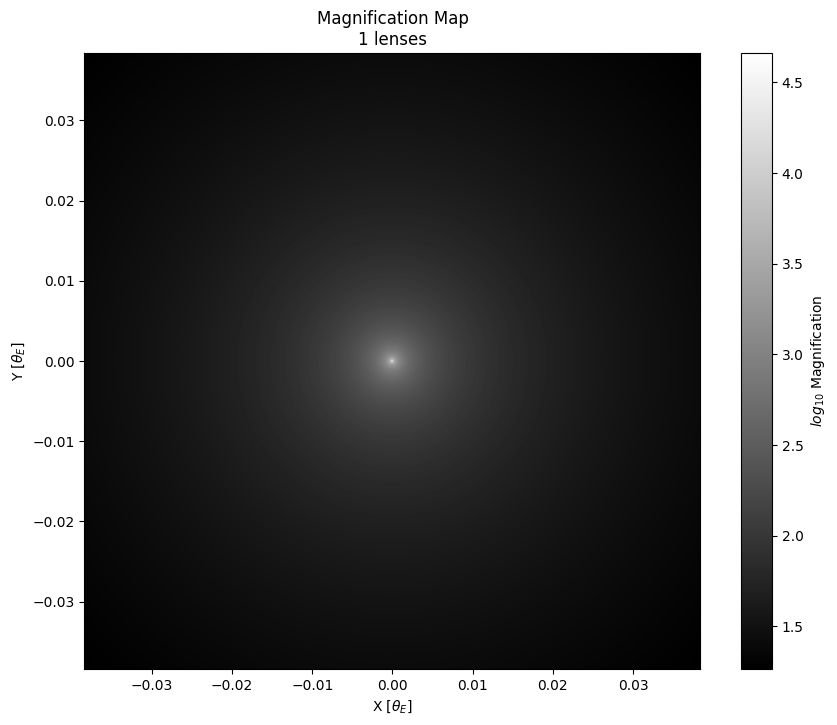

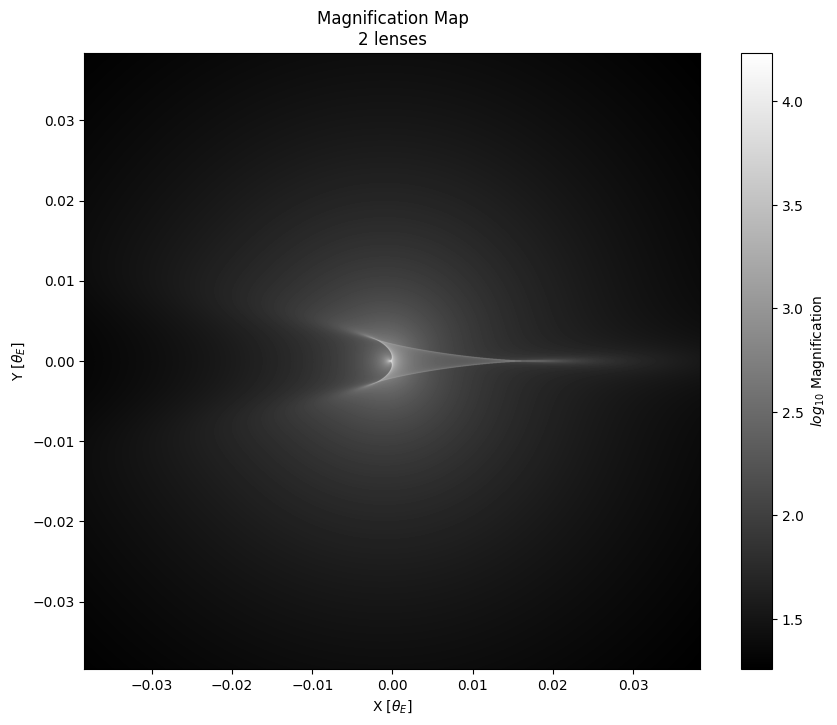

In [24]:
# Single lens
single_lens.plot()

# Binary lens
binary_lens.plot()

#### Calculating VBMicrolensing caustic

In [25]:
all_caustic_points_small_s = []
all_caustic_points_big_s = []

for triple_lens in triple_lenses_small_s:
    parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
    print(parameters)
    VBM.SetLensGeometry(parameters)

    caustic_points = VBM.Multicaustics()

    all_caustic_points_small_s.append(caustic_points)

for triple_lens in triple_lenses_big_s:
    parameters = [item for sublist in triple_lens.lens_att for idx, item in enumerate(sublist)]
    print(parameters)
    VBM.SetLensGeometry(parameters)

    caustic_points = VBM.Multicaustics()

    all_caustic_points_big_s.append(caustic_points)


# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot()

# all_cusp_xs = []
# all_cusp_ys = []
# all_min_indices = []
# all_min_distances = []

# for points in caustic_points:
#     ax.plot(points[0], points[1])
#     xs, ys = IRSF.IRSFunctions.find_cusp_points(np.array(points))
    
#     xs = np.array(xs)
#     ys = np.array(ys)

#     all_cusp_xs.append(xs)
#     all_cusp_ys.append(ys)

#     cusp_distances = np.sqrt(xs**2 + ys**2)
#     min_indices = np.argmin(cusp_distances)

#     all_min_distances.append(cusp_distances[min_indices])
#     all_min_indices.append(min_indices)

# min_ind = np.argmin(np.array(all_min_distances))

# print(all_cusp_xs[min_ind][all_min_indices[min_ind]], all_cusp_ys[min_ind][all_min_indices[min_ind]])

# big_caustic_xs = np.array(caustic_points[min_ind][0])
# big_caustic_ys = np.array(caustic_points[min_ind][1])

# ax.set_xlim(-ang_width/4, ang_width/4)
# ax.set_ylim(-ang_width/4, ang_width/4)
# ax.set_aspect('equal')

# plt.show()

[np.float64(-0.0004868308286694249), np.float64(0.0), np.float64(1.0), np.float64(0.7995131691713306), np.float64(0.0), np.float64(0.001), np.float64(0.09951316917133059), np.float64(0.0), np.float64(1e-06)]
[np.float64(-0.0004868307996990956), np.float64(-6.994056182237637e-11), np.float64(1.0), np.float64(0.7995131692003009), np.float64(-6.994056182237637e-11), np.float64(0.001), np.float64(0.07022384731895567), np.float64(0.07071067804871418), np.float64(1e-06)]
[np.float64(-0.0004868307297585338), np.float64(-9.891089108920626e-11), np.float64(1.0), np.float64(0.7995131692702415), np.float64(-9.891089108920626e-11), np.float64(0.001), np.float64(-0.00048683072975852764), np.float64(0.09999999990108911), np.float64(1e-06)]
[np.float64(-0.000486830659817972), np.float64(-6.994056182237637e-11), np.float64(1.0), np.float64(0.799513169340182), np.float64(-6.994056182237637e-11), np.float64(0.001), np.float64(-0.07119750877847272), np.float64(0.0707106780487142), np.float64(1e-06)]
[np.

#### Defining source parameters

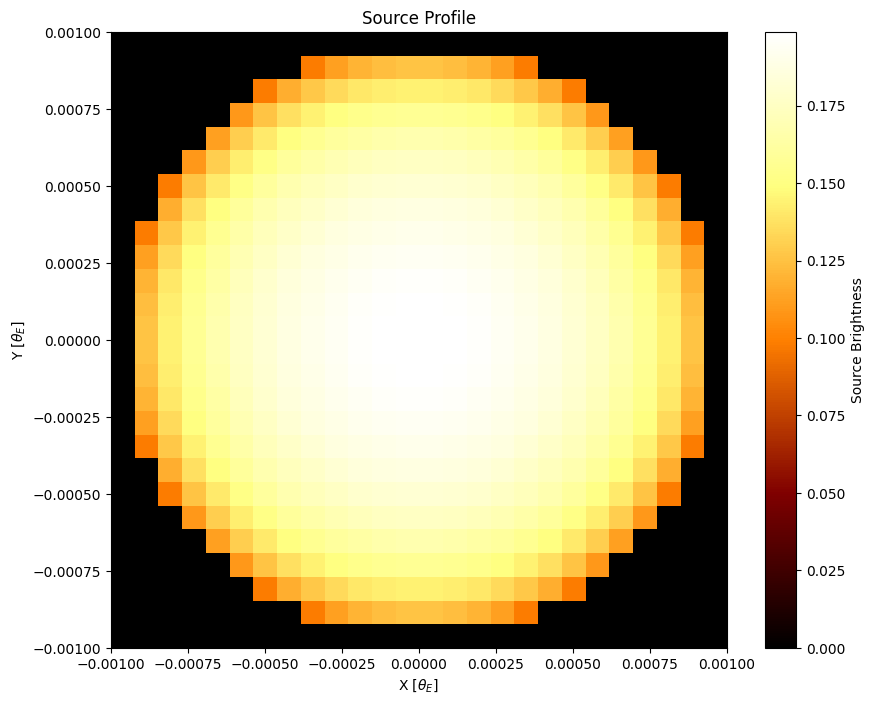

In [26]:
radius = 1e-3
LD = 0.5

source_profile = IRSF.IRSFunctions.source_profile(ang_res=single_lens.param_dict['ang_res'], rad=radius, profile_type='LD', LD=LD)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot()

img = ax.imshow(source_profile, cmap='afmhot', extent=[-radius, radius, -radius, radius])
plt.colorbar(img, ax=ax, label='Source Brightness')

ax.set_xlabel('X [$\\theta_E$]')
ax.set_ylabel('Y [$\\theta_E$]')
ax.set_title('Source Profile')

ax.set_aspect('equal')

plt.show()

#### Convolving all lens configurations

In [27]:
# Single lens
convolved_single_lens = single_lens.convolve(source_profile=source_profile)

# Binary lens
convolved_binary_lens = binary_lens.convolve(source_profile=source_profile)

# All triple lenses
convolved_triple_lenses_small_s = []
convolved_triple_lenses_big_s = []

for triple_lens in triple_lenses_small_s:
    convolved_triple_lenses_small_s.append(triple_lens.convolve(source_profile=source_profile))

for triple_lens in triple_lenses_big_s:
    convolved_triple_lenses_big_s.append(triple_lens.convolve(source_profile=source_profile))

Convolving source profile with magnification map: 0.261 seconds
Convolving source profile with magnification map: 0.213 seconds
Convolving source profile with magnification map: 0.222 seconds
Convolving source profile with magnification map: 0.22 seconds
Convolving source profile with magnification map: 0.223 seconds
Convolving source profile with magnification map: 0.21 seconds
Convolving source profile with magnification map: 0.22 seconds
Convolving source profile with magnification map: 0.217 seconds
Convolving source profile with magnification map: 0.213 seconds
Convolving source profile with magnification map: 0.215 seconds
Convolving source profile with magnification map: 0.221 seconds
Convolving source profile with magnification map: 0.222 seconds
Convolving source profile with magnification map: 0.221 seconds
Convolving source profile with magnification map: 0.222 seconds
Convolving source profile with magnification map: 0.22 seconds
Convolving source profile with magnification

#### Calculating fractional deviations from single and binary for all triple lens configurations

In [28]:
# Single lens deviations
fractional_deviation_single_small_s = []
fractional_deviation_single_big_s = []

# Binary lens deviations
fractional_deviation_binary_small_s = []
fractional_deviation_binary_big_s = []

for convolved_triple_lens in convolved_triple_lenses_small_s:
    fractional_deviation_single_small_s.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
    fractional_deviation_binary_small_s.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

for convolved_triple_lens in convolved_triple_lenses_big_s:
    fractional_deviation_single_big_s.append( (convolved_triple_lens - convolved_single_lens)/convolved_single_lens )
    fractional_deviation_binary_big_s.append( (convolved_triple_lens - convolved_binary_lens)/convolved_binary_lens )

#### Plotting all fractional deviations

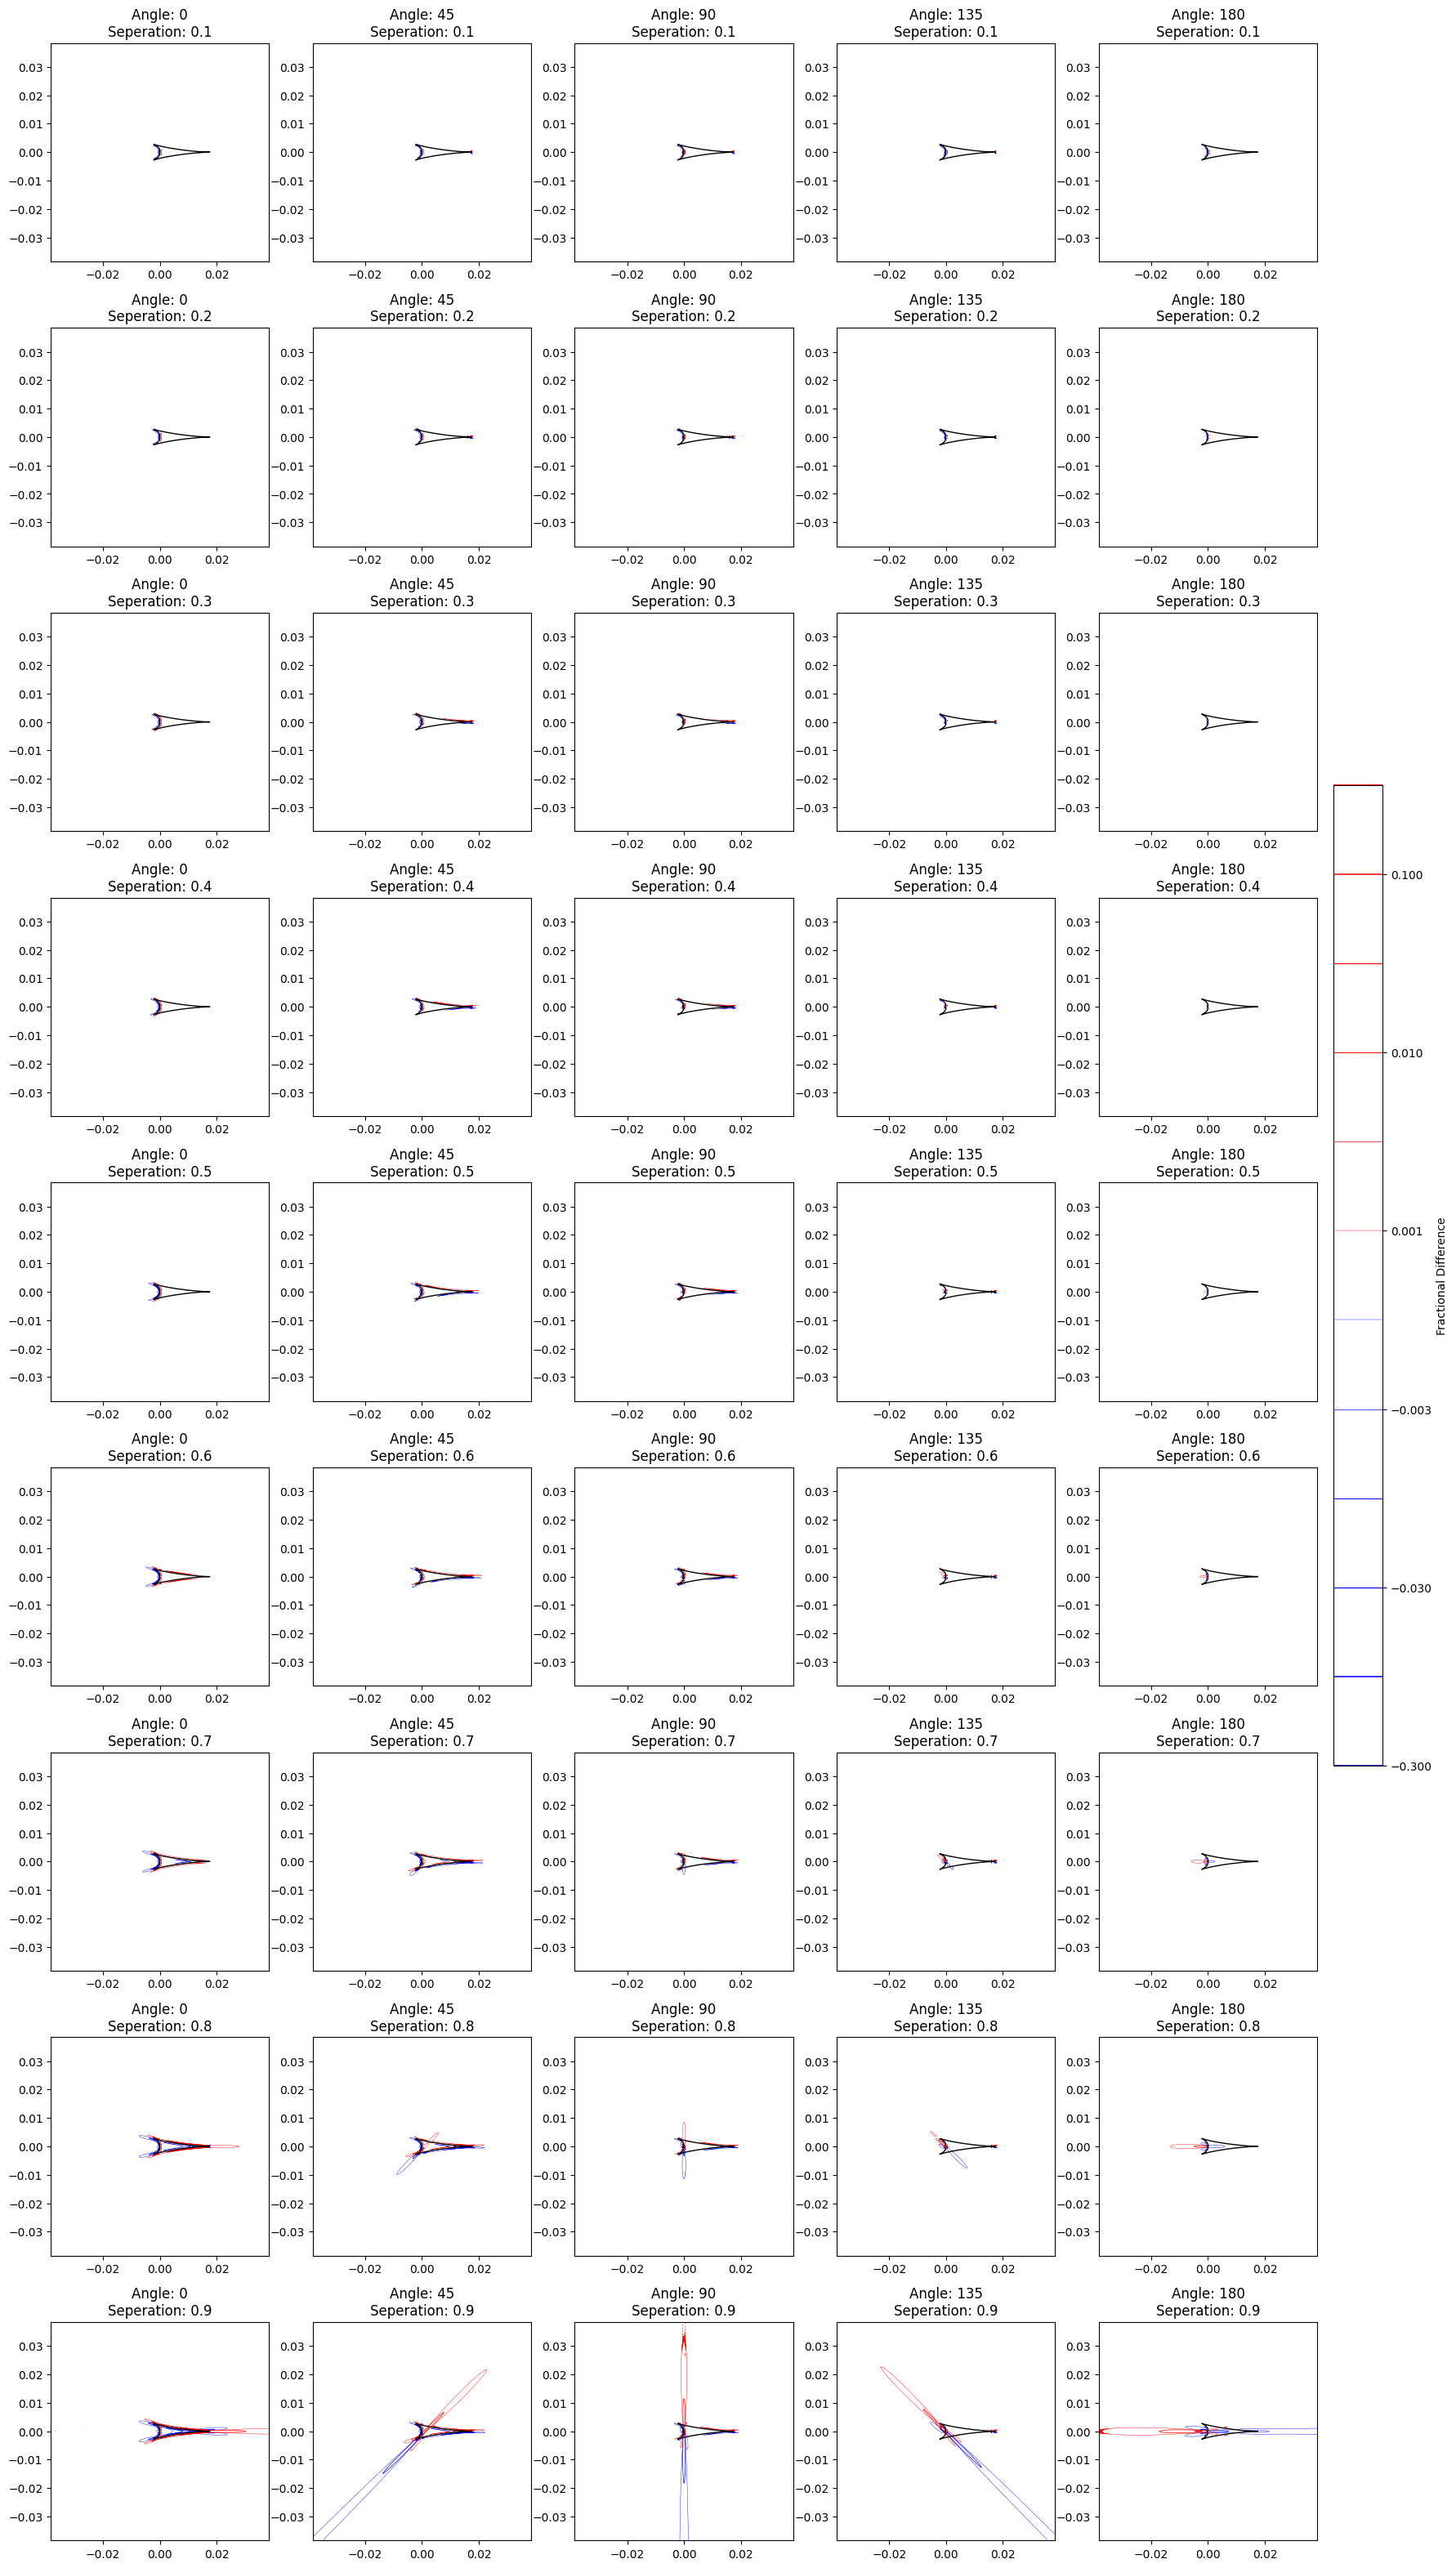

In [35]:
fig = plt.figure(figsize=(20, 40))
all_axes = fig.subplots(9, 5)
axes = all_axes

# fig.suptitle('\nFractional Differences from Binary Lens for Triple Lens', fontsize=16)
# fig.set_tight_layout(True)

flat_ind = 0
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {alphas[j]}\nSeperation: {seperations1[i]}')

        caustic_points = all_caustic_points_small_s[flat_ind]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_small_s[flat_ind], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)

        ax.set_aspect('equal')

        flat_ind += 1
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

fig.savefig('Fractional Difference Contours s < 1.png', dpi=500)

plt.show()

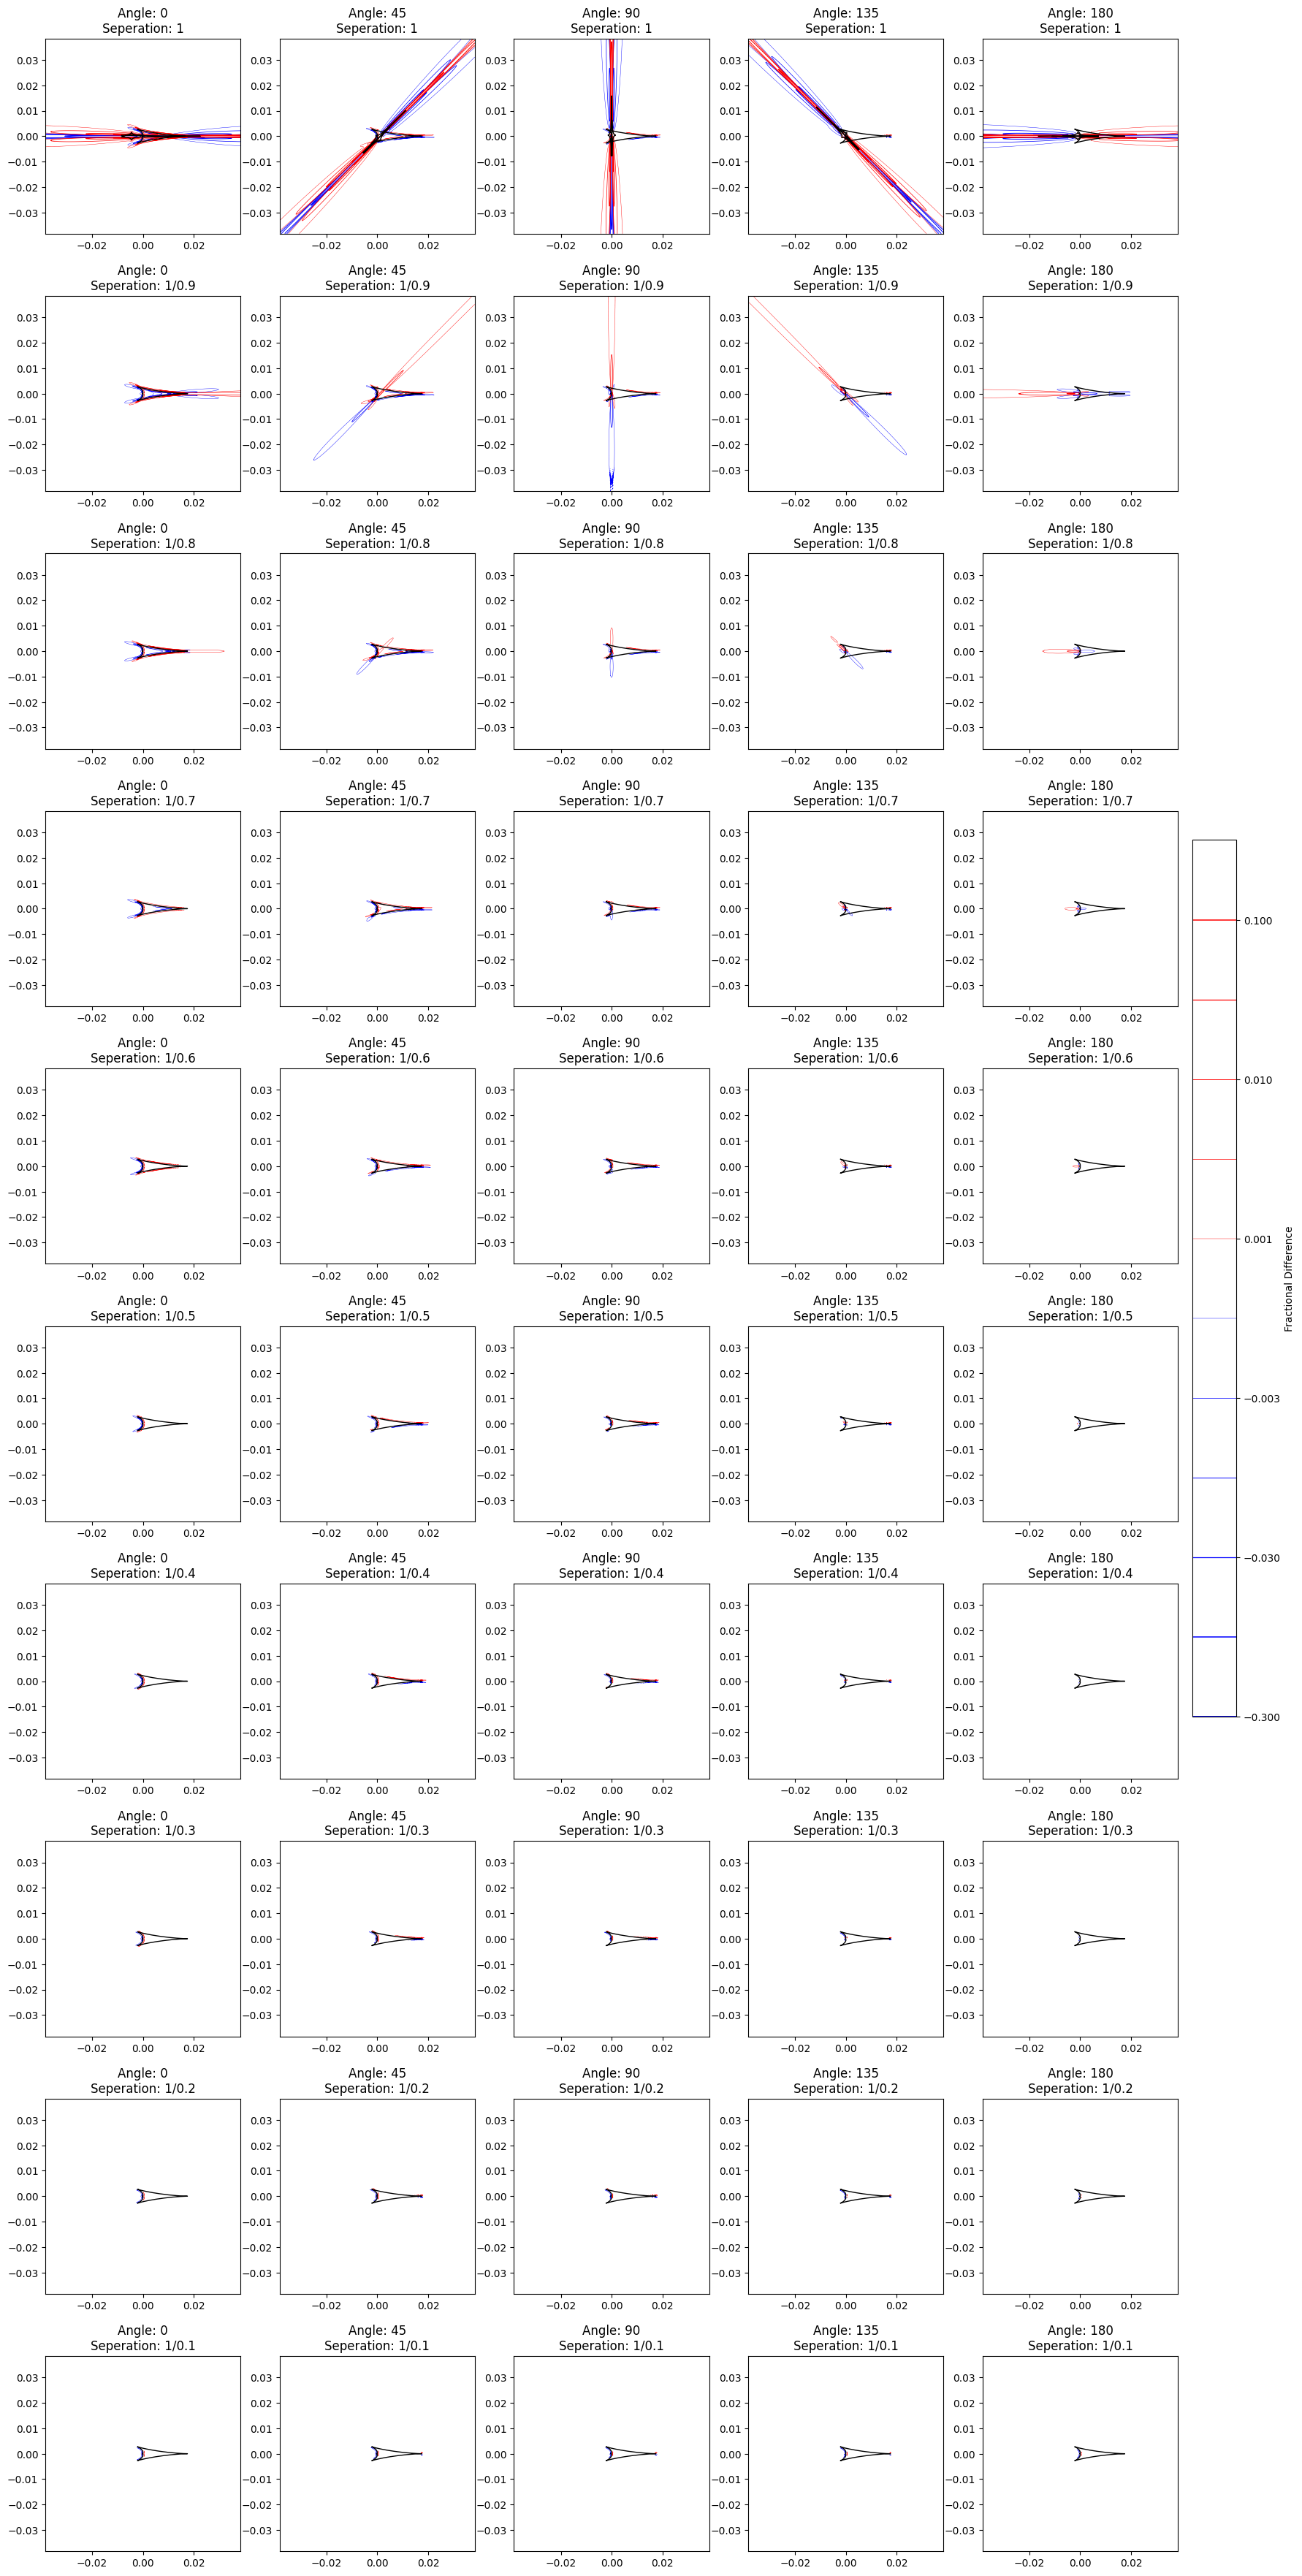

In [36]:
fig = plt.figure(figsize=(20, 45))
all_axes = fig.subplots(10, 5)
axes = all_axes

# fig.suptitle('\nFractional Differences from Binary Lens for Triple Lens', fontsize=16)
# fig.set_tight_layout(True)

flat_ind = 0
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {alphas[j]}\nSeperation: {seperations2_string[i]}')

        caustic_points = all_caustic_points_big_s[flat_ind]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)

        img = ax.contour(single_lens.X_pix, single_lens.Y_pix, np.flip(fractional_deviation_binary_big_s[flat_ind], axis=0),
                levels=[-0.30, -0.10, -0.03, -0.01, -0.003, -0.001, 0.001, 0.003, 0.01, 0.03, 0.10, 0.30],
                colors=['blue', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'red', 'red', 'red', 'red', 'red'],
                linewidths=[1.3, 1.1, 0.9, 0.7, 0.5, 0.3, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3],
                zorder=0
        )

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)

        ax.set_aspect('equal')

        flat_ind += 1
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

fig.savefig('Fractional Difference Contours s > 1.png', dpi=500)

plt.show()

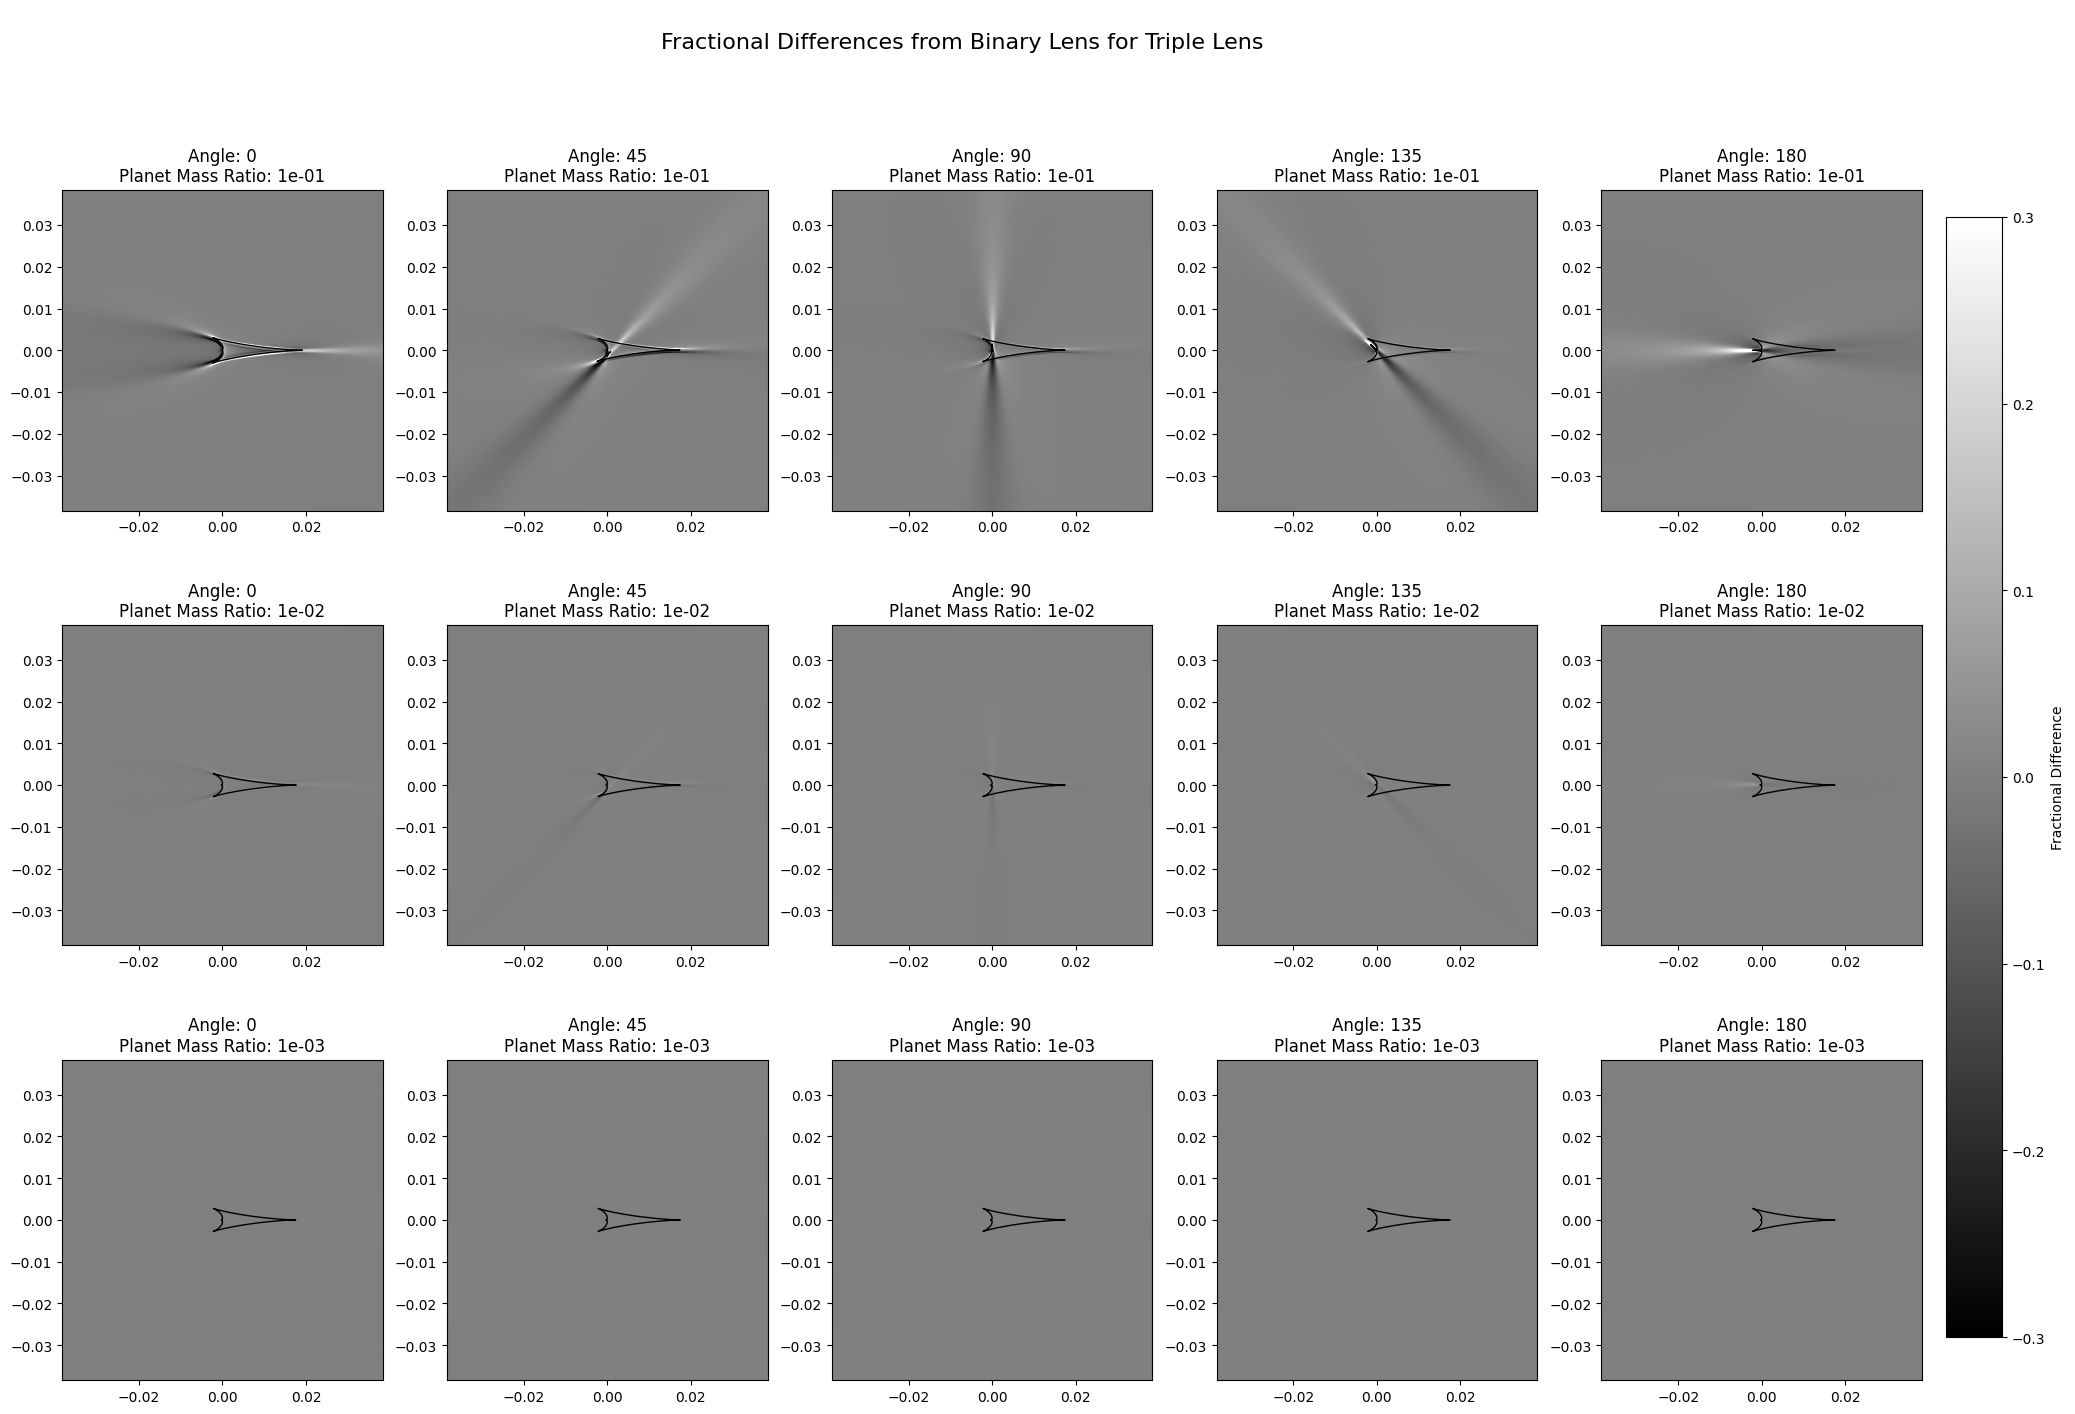

In [ ]:
fig = plt.figure(figsize=(24, 16))
all_axes = fig.subplots(3, 5)
axes = all_axes

fig.suptitle('\nFractional Differences from Binary Lens for Triple Lens', fontsize=16)

flat_ind = 0
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_title(f'Angle: {alphas[j]}\nPlanet Mass Ratio: {(pmrs[i]):.0e}')

        caustic_points = all_caustic_points[flat_ind]
        for caustic in caustic_points:
            ax.plot(caustic[0], caustic[1], color='black', linewidth=1, zorder=10)
        
        img = ax.imshow(fractional_deviation_binary[flat_ind], cmap='gray', extent=[-ang_width/2, ang_width/2, -ang_width/2, ang_width/2], vmin=-0.3, vmax=0.3)

        ax.set_xlim(-ang_width/2, ang_width/2)
        ax.set_ylim(-ang_width/2, ang_width/2)

        flat_ind += 1
        
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar_ax.axis('off')

bar = fig.colorbar(img, ax=cbar_ax, location='right', fraction=1.5, aspect=20)
bar.set_label('Fractional Difference')

# fig.savefig('Fractional Difference Colormaps.png', dpi=500)

plt.show()